# Data Exploaration Notebook 
We have three files `goodreads_books_young_adult.json`, `goodreads_reviews_young_adult.json`, and `goodreads_interactions_young_adult.json`. 
`goodreads_books_young_adult.json` gives us the metadata for each book, `goodreads_reviews_young_adult.json` gives us record of each review
`goodreads_interactions_young_adult.json` gives us a record of each user-book interaction.

In [ ]:
import os
from pathlib import Path
import duckdb
import polars as pl
import matplotlib.pyplot as plt

In [2]:
books_path = 'data/goodreads_books_young_adult.json'
reviews_path = 'data/goodreads_reviews_young_adult.json'
interactions_path = 'data/goodreads_interactions_young_adult.json'

In [6]:
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(80)

# One DuckDB connection
con = duckdb.connect()
con.execute("PRAGMA memory_limit='6GB'")
con.execute("PRAGMA threads=8")
con

# Analyze metadata file
Lets do a deep dive into `goodreads_books_young_adult.json`

In [8]:
# Lets start by creating a lazy polars reader
book_lazy_load = pl.scan_ndjson(books_path, infer_schema_length=2000) # only look at the first 2000 to get column type
schema = book_lazy_load.collect_schema() # get schema 

In [12]:
for name, dtype in schema.items():
    print(f'{name:35s}{dtype}')

isbn                               String
text_reviews_count                 String
series                             List(String)
country_code                       String
language_code                      String
popular_shelves                    List(Struct({'count': String, 'name': String}))
asin                               String
is_ebook                           String
average_rating                     String
kindle_asin                        String
similar_books                      List(String)
description                        String
format                             String
link                               String
authors                            List(Struct({'author_id': String, 'role': String}))
publisher                          String
num_pages                          String
publication_day                    String
isbn13                             String
publication_month                  String
edition_information                String
publication_year    

In [13]:
len(schema)

29

In [15]:
total_books = book_lazy_load.select(pl.len()).collect().item()
print(f"total of {total_books} books")

total of 93398 books


In [ ]:
key_columns = [
    'isbn', 'isbn13', 'title', 'description', 'language_code', 'average_rating',
    'publisher', 'publication_year', 'format', 'image_url', 'url',
] # these are key columns that have important info

In [23]:
key_columns = [c for c in key_columns if c in schema]


In [ ]:
missing = (
    book_lazy_load
    .select([
        ((pl.col(c).is_null()) | (pl.col(c).cast(pl.Utf8) == '')).mean().alias(c) # check if null or is blank
        for c in key_columns
    ])
    .collect()
    .transpose(include_header=True, header_name='field', column_names=['missing_frac'])
    .sort('missing_frac', descending=True)
)

In [25]:
missing

field,missing_frac
str,f64
"""isbn""",0.40518
"""language_code""",0.317266
"""isbn13""",0.287137
"""format""",0.19282
"""publication_year""",0.165989
"""description""",0.045911
"""title""",0.0
"""average_rating""",0.0
"""image_url""",0.0


In [28]:
books_ratings = (
    book_lazy_load
    .with_columns([
        pl.col('average_rating').cast(pl.Float64, strict=False),
        pl.col('ratings_count').cast(pl.Int64, strict=False),
        pl.col('text_reviews_count').cast(pl.Int64, strict=False),
    ])
    .select(['average_rating', 'ratings_count', 'text_reviews_count'])
    .collect()
)
len(books_ratings)

93398

In [29]:
books_ratings.describe()

statistic,average_rating,ratings_count,text_reviews_count
str,f64,f64,f64
"""count""",93398.0,93398.0,93398.0
"""null_count""",0.0,0.0,0.0
"""mean""",3.860503,1351.241536,101.913189
"""std""",0.345687,28857.589171,1159.965407
"""min""",0.0,0.0,0.0
"""25%""",3.66,15.0,3.0
"""50%""",3.87,48.0,9.0
"""75%""",4.09,184.0,29.0
"""max""",5.0,4.899965e6,142645.0


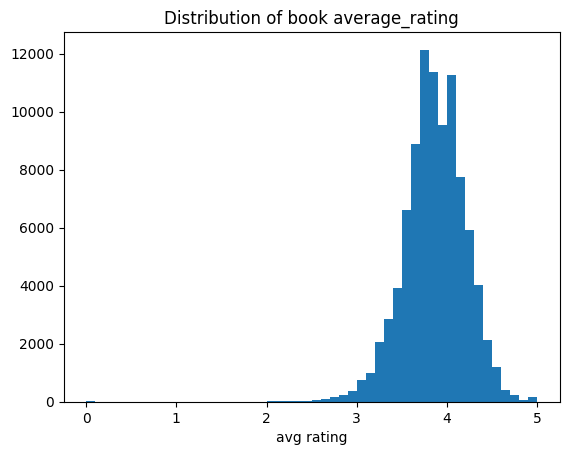

In [33]:
plt.hist(books_ratings['average_rating'].drop_nulls().to_numpy(), bins=50)
plt.title('Distribution of book average_rating')
plt.xlabel('avg rating')
plt.show()  # optional, to display the plot

In [34]:
# pblication year distribution
year_dist = (
    book_lazy_load
    .with_columns(pl.col('publication_year').cast(pl.Int32, strict=False))
    .filter(pl.col('publication_year').is_between(1900, 2025))
    .group_by('publication_year').agg(pl.len().alias('n'))
    .sort('publication_year')
    .collect()
)

In [35]:
year_dist

publication_year,n
i32,u32
1905,1
1909,1
1922,2
1924,2
1925,1
1927,1
1930,1
1933,1
1934,1


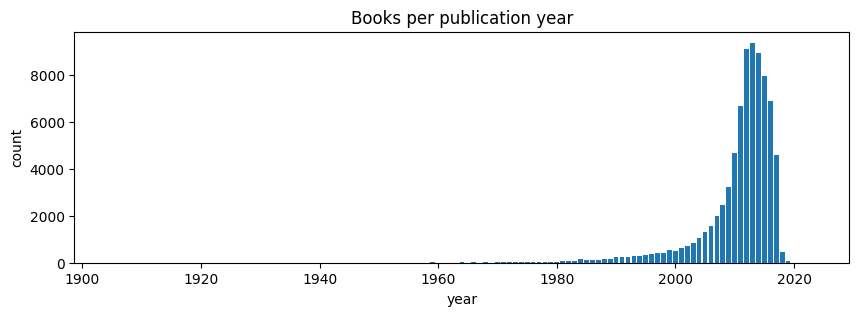

In [36]:
plt.figure(figsize=(10, 3))
plt.bar(year_dist['publication_year'].to_numpy(), year_dist['n'].to_numpy())
plt.title('Books per publication year')
plt.xlabel('year')
plt.ylabel('count')
plt.show()

In [37]:
book_lazy_load.group_by('language_code').agg(pl.len().alias('n')).sort('n', descending=True).head(15).collect()

language_code,n
str,u32
"""eng""",35989
"""""",29632
"""en-US""",4996
"""en-GB""",2922
"""ger""",2798
"""spa""",2511
"""fre""",1788
"""ita""",1761
"""ind""",1623


In [38]:
book_lazy_load.group_by('format').agg(pl.len().alias('n')).sort('n', descending=True).head(15).collect()

format,n
str,u32
"""Paperback""",35946
"""""",18009
"""Hardcover""",15684
"""ebook""",9467
"""Kindle Edition""",7136
"""Audio CD""",2085
"""Audiobook""",1537
"""Mass Market Paperback""",1237
"""Audible Audio""",584
